# Camera-only BEV Fusion pipeline

In [23]:
# ============================================================
# Allow notebook to import MMDetection3D + BEVFusion project
# ============================================================

import sys
from pathlib import Path

MMDET3D_ROOT = "/home/edgelab/mmdetection3d"

if MMDET3D_ROOT not in sys.path:
    sys.path.insert(0, MMDET3D_ROOT)

# verify path works
assert Path(MMDET3D_ROOT, "projects", "BEVFusion").exists()

print("MMDetection3D root added:", MMDET3D_ROOT)

MMDetection3D root added: /home/edgelab/mmdetection3d


In [24]:
from mmengine.registry import init_default_scope
init_default_scope("mmdet3d")

# This line registers GeneralizedLSSFPN and DepthLSSTransform
import projects.BEVFusion.bevfusion

device: cuda
Loaded arrays:
K_final: (3, 3)
camera2ego: (4, 4)
ego2image: (3, 4)
img_aug_matrix: (4, 4)
fusion_aug_matrix: (4, 4)


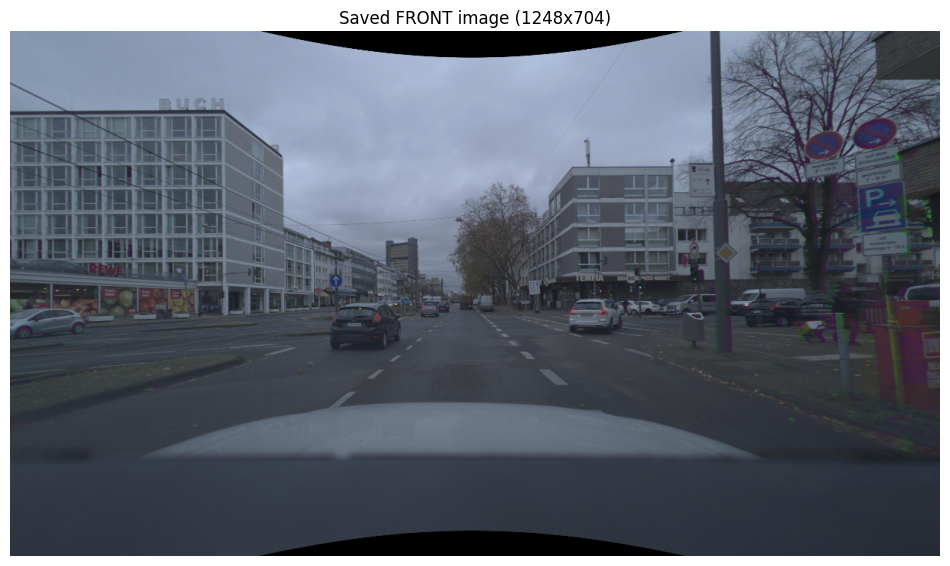

img_tensor: (1, 1, 3, 704, 1248)
fov_points_ego_xyzi: (73883, 4)
first point: [47.478405 56.58517   8.407365 62.      ]

Runtime tensor shapes:
camera_intrinsics: (1, 1, 3, 3)
camera2fusion: (1, 1, 4, 4)
fusion2image: (1, 1, 3, 4)
img_aug_matrix: (1, 1, 4, 4)
fusion_aug_matrix: (1, 4, 4)
points[0]: (73883, 4)

Camera position in ego frame: [2.0153067e+00 4.9021305e-04 1.1250600e+00]
Principal point: (619.68317, 364.74072)


In [25]:
# ============================================================
# Load ego-frame BEVFusion camera artifacts for one FRONT frame
# ============================================================

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

ROOT = Path("/home/edgelab/multimodal-MoE/outputs/tmp")
FRAME_ID = "060350"

npz_path = ROOT / f"{FRAME_ID}_bev_inputs.npz"
img_path = ROOT / f"{FRAME_ID}_front_undistorted_resized_1248x704.png"
bin_path = ROOT / f"{FRAME_ID}_fov_points_ego_xyzi.bin"

assert npz_path.exists(), f"Missing npz: {npz_path}"
assert img_path.exists(), f"Missing image: {img_path}"
assert bin_path.exists(), f"Missing ego-frame points bin: {bin_path}"

# ------------------------------------------------------------
# Load saved arrays
# ------------------------------------------------------------
data = np.load(npz_path)

K_final_np = data["K_final"].astype(np.float32)                    # [3,3]
camera2ego_np = data["camera2ego"].astype(np.float32)             # [4,4]
ego2image_np = data["ego2image"].astype(np.float32)               # [3,4]
img_aug_matrix_np = data["img_aug_matrix"].astype(np.float32)     # [4,4]
fusion_aug_matrix_np = data["fusion_aug_matrix"].astype(np.float32)  # [4,4]

print("Loaded arrays:")
print("K_final:", K_final_np.shape)
print("camera2ego:", camera2ego_np.shape)
print("ego2image:", ego2image_np.shape)
print("img_aug_matrix:", img_aug_matrix_np.shape)
print("fusion_aug_matrix:", fusion_aug_matrix_np.shape)

# ------------------------------------------------------------
# Load final saved image
# ------------------------------------------------------------
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
assert img_bgr is not None, f"Could not read image: {img_path}"

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W = img_rgb.shape[:2]

plt.figure(figsize=(12, 7))
plt.imshow(img_rgb)
plt.title(f"Saved FRONT image ({W}x{H})")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# Normalize image
# ------------------------------------------------------------
mean = np.array([123.675, 116.28, 103.53], dtype=np.float32).reshape(1, 1, 3)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32).reshape(1, 1, 3)

img_norm = (img_rgb.astype(np.float32) - mean) / std

# [H,W,C] (this is the shape we get from opencv) -> [C,H,W] -> [B,N,C,H,W] (this is what mm3Dobjdet expects)
# N stands for number of cameras, always 1 in our case since we only have front camera
img_tensor = torch.from_numpy(img_norm).permute(2, 0, 1).contiguous()
img_tensor = img_tensor.unsqueeze(0).unsqueeze(0).to(device)

print("img_tensor:", tuple(img_tensor.shape))

# ------------------------------------------------------------
# Load ego-frame points
# ------------------------------------------------------------
raw = np.fromfile(bin_path, dtype=np.float32)
assert raw.size % 4 == 0, f"Expected multiple of 4 floats, got {raw.size}"

fov_points_ego_xyzi = raw.reshape(-1, 4)
print("fov_points_ego_xyzi:", fov_points_ego_xyzi.shape)
print("first point:", fov_points_ego_xyzi[0] if len(fov_points_ego_xyzi) else "EMPTY")

points = [torch.from_numpy(fov_points_ego_xyzi).to(device)]

# ------------------------------------------------------------
# Build runtime tensors
# NOTE:
# Even if downstream code still uses names like camera2lidar or
# lidar2image, in OUR ego-frame setup these slots hold:
#
#   camera2fusion = camera2ego
#   fusion2image  = ego2image
# ------------------------------------------------------------
camera_intrinsics = torch.from_numpy(K_final_np).unsqueeze(0).unsqueeze(0).to(device)      # [1,1,3,3]
camera2fusion = torch.from_numpy(camera2ego_np).unsqueeze(0).unsqueeze(0).to(device)       # [1,1,4,4]
fusion2image = torch.from_numpy(ego2image_np).unsqueeze(0).unsqueeze(0).to(device)         # [1,1,3,4]
img_aug_matrix = torch.from_numpy(img_aug_matrix_np).unsqueeze(0).unsqueeze(0).to(device)  # [1,1,4,4]
fusion_aug_matrix = torch.from_numpy(fusion_aug_matrix_np).unsqueeze(0).to(device)         # [1,4,4]

metas = [dict(frame_id=str(FRAME_ID), camera_name="FC")]

print("\nRuntime tensor shapes:")
print("camera_intrinsics:", tuple(camera_intrinsics.shape))
print("camera2fusion:", tuple(camera2fusion.shape))
print("fusion2image:", tuple(fusion2image.shape))
print("img_aug_matrix:", tuple(img_aug_matrix.shape))
print("fusion_aug_matrix:", tuple(fusion_aug_matrix.shape))
print("points[0]:", tuple(points[0].shape))

print("\nCamera position in ego frame:", camera2ego_np[:3, 3])
print("Principal point:", (K_final_np[0, 2], K_final_np[1, 2]))

In [ ]:
# ============================================================
# Build camera-only BEVFusion modules (ego-frame fusion setup)
# ============================================================

import os
import torch
from mmdet.models.backbones import SwinTransformer
from mmdet3d.registry import MODELS as MMDET3D_MODELS

# ------------------------------------------------------------
# Shared BEV grid in ego frame
# x = forward, y = left/right
# ------------------------------------------------------------
XBOUND = [0.0, 250.0, 0.5]
YBOUND = [-90.0, 90.0, 0.5]
ZBOUND = [-10.0, 10.0, 20.0]   # one vertical slice
DBOUND = [1.0, 80.0, 0.5]      # depth bins along camera rays

CHECKPOINT_PATH = "/home/edgelab/checkpoints/bevfusion_pretrained.pth"

print("GeneralizedLSSFPN registered:",
      "GeneralizedLSSFPN" in MMDET3D_MODELS.module_dict)
print("DepthLSSTransform registered:",
      "DepthLSSTransform" in MMDET3D_MODELS.module_dict)

# ------------------------------------------------------------
# Image backbone
# ------------------------------------------------------------
img_backbone = SwinTransformer(
    pretrain_img_size=224,
    in_channels=3,
    embed_dims=96,
    depths=[2, 2, 6, 2],
    num_heads=[3, 6, 12, 24],
    window_size=7,
    mlp_ratio=4,
    qkv_bias=True,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    drop_path_rate=0.2,
    patch_norm=True,
    out_indices=(1, 2, 3),
    with_cp=False,
    convert_weights=True,
)

# ------------------------------------------------------------
# Image neck
# ------------------------------------------------------------
img_neck = MMDET3D_MODELS.build(
    dict(
        type="GeneralizedLSSFPN",
        in_channels=[192, 384, 768],
        out_channels=256,
        start_level=0,
        num_outs=3,
        norm_cfg=dict(type="BN2d", requires_grad=True),
        act_cfg=dict(type="ReLU", inplace=True),
        upsample_cfg=dict(mode="bilinear", align_corners=False),
    )
)

# ------------------------------------------------------------
# Camera view transform
# NOTE:
# Even though the API names are lidar-centric, we are using
# ego as the common fusion frame consistently.
# ------------------------------------------------------------
view_transform = MMDET3D_MODELS.build(
    dict(
        type="DepthLSSTransform",
        in_channels=256,
        out_channels=80,
        image_size=[704, 1248],
        feature_size=[88, 156],
        xbound=XBOUND,
        ybound=YBOUND,
        zbound=ZBOUND,
        dbound=DBOUND,
        downsample=2,
    )
)

img_backbone.to(device).eval()
img_neck.to(device).eval()
view_transform.to(device).eval()

# ------------------------------------------------------------
# Optional checkpoint loading
# Expects keys like:
#   img_backbone.*
#   img_neck.*
#   view_transform.*
# ------------------------------------------------------------
if os.path.exists(CHECKPOINT_PATH):
    print(f"\nLoading checkpoint: {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu")
    state_dict = ckpt.get("state_dict", ckpt)

    cleaned = {}
    for k, v in state_dict.items():
        cleaned[k[7:] if k.startswith("module.") else k] = v

    for prefix, module in [
        ("img_backbone", img_backbone),
        ("img_neck", img_neck),
        ("view_transform", view_transform),
    ]:
        sub_state = {
            k[len(prefix) + 1:]: v
            for k, v in cleaned.items()
            if k.startswith(prefix + ".")
        }
        if len(sub_state) == 0:
            print(f"[WARN] No checkpoint keys found for {prefix}")
        else:
            msg = module.load_state_dict(sub_state, strict=False)
            print(f"{prefix}: missing={len(msg.missing_keys)}, unexpected={len(msg.unexpected_keys)}")
else:
    print(f"\n[WARN] Checkpoint not found: {CHECKPOINT_PATH}")
    print("[WARN] Modules will run with random weights.")

print("\nBuilt modules:")
print("img_backbone:", type(img_backbone))
print("img_neck:", type(img_neck))
print("view_transform:", type(view_transform))

print("\nConfigured BEV bounds:")
print("XBOUND:", XBOUND)
print("YBOUND:", YBOUND)
print("ZBOUND:", ZBOUND)
print("DBOUND:", DBOUND)

GeneralizedLSSFPN registered: True
DepthLSSTransform registered: True

[WARN] Checkpoint not found: /home/edgelab/checkpoints/bevfusion_pretrained.pth
[WARN] Modules will run with random weights.

Built modules:
img_backbone: <class 'mmdet.models.backbones.swin.SwinTransformer'>
img_neck: <class 'projects.BEVFusion.bevfusion.bevfusion_necks.GeneralizedLSSFPN'>
view_transform: <class 'projects.BEVFusion.bevfusion.depth_lss.DepthLSSTransform'>

Configured BEV bounds:
XBOUND: [0.0, 250.0, 0.5]
YBOUND: [-90.0, 90.0, 0.5]
ZBOUND: [-10.0, 10.0, 20.0]
DBOUND: [1.0, 60.0, 0.5]


In [ ]:
# ============================================================
# Build camera-only BEVFusion modules
# simple version: no checkpoint loading
# ego frame is the common fusion frame
# ============================================================

import torch
from mmdet.models.backbones import SwinTransformer
from mmdet3d.registry import MODELS as MMDET3D_MODELS

# Shared BEV grid in ego frame
XBOUND = [0.0, 250.0, 0.5]
YBOUND = [-90.0, 90.0, 0.5]
ZBOUND = [-10.0, 10.0, 20.0]
DBOUND = [1.0, 60.0, 0.5]

print("GeneralizedLSSFPN registered:",
      "GeneralizedLSSFPN" in MMDET3D_MODELS.module_dict)
print("DepthLSSTransform registered:",
      "DepthLSSTransform" in MMDET3D_MODELS.module_dict)

# Image backbone
img_backbone = SwinTransformer(
    pretrain_img_size=224,
    in_channels=3,
    embed_dims=96,
    depths=[2, 2, 6, 2],
    num_heads=[3, 6, 12, 24],
    window_size=7,
    mlp_ratio=4,
    qkv_bias=True,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    drop_path_rate=0.2,
    patch_norm=True,
    out_indices=(1, 2, 3),
    with_cp=False,
    convert_weights=True,
)

# Image neck
img_neck = MMDET3D_MODELS.build(
    dict(
        type="GeneralizedLSSFPN",
        in_channels=[192, 384, 768],
        out_channels=256,
        start_level=0,
        num_outs=3,
        norm_cfg=dict(type="BN2d", requires_grad=True),
        act_cfg=dict(type="ReLU", inplace=True),
        upsample_cfg=dict(mode="bilinear", align_corners=False),
    )
)

# Camera view transform
# We are using ego as the common fusion frame
# With stride-8 features, a 19-pixel pedestrian becomes about 2–3 feature cells, which is small but still usable for detection.
view_transform = MMDET3D_MODELS.build(
    dict(
        type="DepthLSSTransform",
        in_channels=256,
        out_channels=80,
        image_size=[704, 1248],
        feature_size=[88, 156], 
        xbound=XBOUND,
        ybound=YBOUND,
        zbound=ZBOUND,
        dbound=DBOUND,
        downsample=2,
    )
)

img_backbone.to(device).eval()
img_neck.to(device).eval()
view_transform.to(device).eval()

print("\nBuilt modules:")
print("img_backbone:", type(img_backbone))
print("img_neck:", type(img_neck))
print("view_transform:", type(view_transform))

print("\nConfigured BEV bounds:")
print("XBOUND:", XBOUND)
print("YBOUND:", YBOUND)
print("ZBOUND:", ZBOUND)
print("DBOUND:", DBOUND)

GeneralizedLSSFPN registered: True
DepthLSSTransform registered: True

Built modules:
img_backbone: <class 'mmdet.models.backbones.swin.SwinTransformer'>
img_neck: <class 'projects.BEVFusion.bevfusion.bevfusion_necks.GeneralizedLSSFPN'>
view_transform: <class 'projects.BEVFusion.bevfusion.depth_lss.DepthLSSTransform'>

Configured BEV bounds:
XBOUND: [0.0, 250.0, 0.5]
YBOUND: [-90.0, 90.0, 0.5]
ZBOUND: [-10.0, 10.0, 20.0]
DBOUND: [1.0, 60.0, 0.5]


In [28]:
# ============================================================
# Forward pass: image -> backbone -> neck -> view transform -> BEV
# ego is the common fusion frame
# ============================================================

with torch.no_grad():
    B, N, C, H, W = img_tensor.shape

    assert isinstance(points, list), f"points must be list, got {type(points)}"
    assert len(points) == img_tensor.shape[0], f"len(points)={len(points)} != batch={img_tensor.shape[0]}"
    assert points[0].ndim == 2 and points[0].shape[1] >= 3, f"bad points[0] shape: {points[0].shape}"
    # Flatten camera dimension for backbone
    imgs_flat = img_tensor.view(B * N, C, H, W)
    print("imgs_flat:", tuple(imgs_flat.shape))

    # Backbone features
    backbone_feats = img_backbone(imgs_flat)
    print("num backbone feats:", len(backbone_feats))
    for i, feat in enumerate(backbone_feats):
        print(f"backbone_feats[{i}]:", tuple(feat.shape))

    # Neck features
    neck_feats = img_neck(backbone_feats)
    print("num neck feats:", len(neck_feats))
    for i, feat in enumerate(neck_feats):
        print(f"neck_feats[{i}]:", tuple(feat.shape))

    # DepthLSSTransform uses the first neck feature map
    img_feats = neck_feats[0]                    # [B*N, Cn, Hf, Wf]
    _, Cn, Hf, Wf = img_feats.shape
    img_feats = img_feats.view(B, N, Cn, Hf, Wf)

    print("img_feats for view transform:", tuple(img_feats.shape))

    # IMPORTANT:
    # API names are still lidar-centric, but in our setup:
    #   camera2lidar slot  <- camera2ego
    #   lidar2image slot   <- ego2image
    #   lidar_aug_matrix   <- fusion_aug_matrix
    bev_feats = view_transform(
        img_feats,
        points,
        fusion2image,        # acts as "lidar2image" slot
        camera_intrinsics,
        camera2fusion,       # acts as "camera2lidar" slot
        img_aug_matrix,
        fusion_aug_matrix,   # acts as "lidar_aug_matrix" slot
        metas,
    )

print("\nbev_feats:", tuple(bev_feats.shape))

imgs_flat: (1, 3, 704, 1248)
num backbone feats: 3
backbone_feats[0]: (1, 192, 88, 156)
backbone_feats[1]: (1, 384, 44, 78)
backbone_feats[2]: (1, 768, 22, 39)
num neck feats: 2
neck_feats[0]: (1, 256, 88, 156)
neck_feats[1]: (1, 256, 44, 78)
img_feats for view transform: (1, 1, 256, 88, 156)

bev_feats: (1, 80, 250, 180)


bev_feats shape: (1, 80, 250, 180)
BEV 2D map shape: (250, 180)


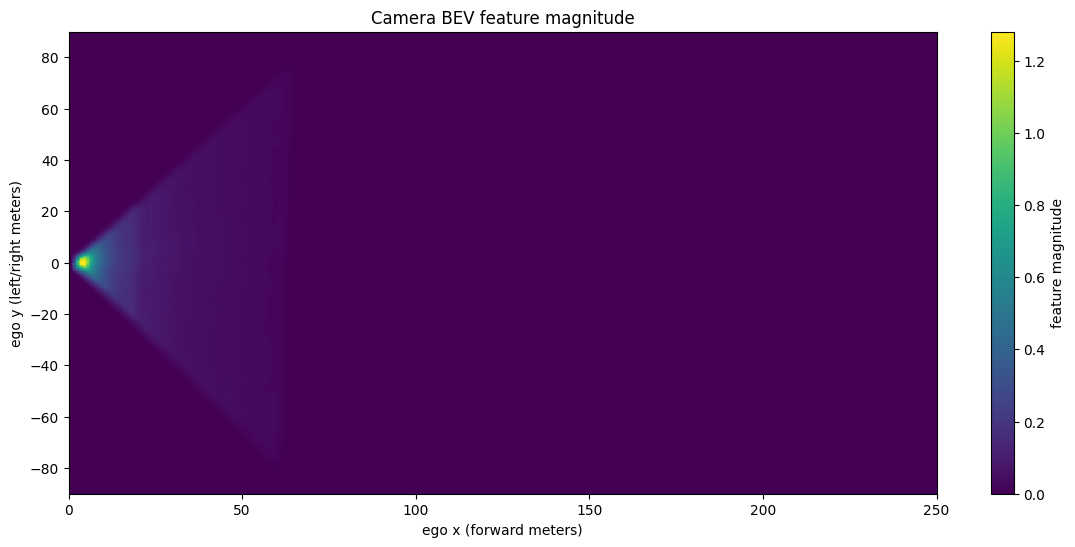

In [29]:
# ============================================================
# Plot BEV feature map from camera branch
# bev_feats shape: [B, C, X, Y]
# ============================================================

import matplotlib.pyplot as plt
import torch

# Remove batch dimension
bev0 = bev_feats[0].detach().cpu()          # [C, X, Y]

# Collapse channels to a single 2D map
bev_l2 = torch.norm(bev0, dim=0).numpy()    # [X, Y]

print("bev_feats shape:", tuple(bev_feats.shape))
print("BEV 2D map shape:", bev_l2.shape)

# BEV bounds (ego frame)
x_min, x_max, _ = XBOUND
y_min, y_max, _ = YBOUND

plt.figure(figsize=(14,6))

plt.imshow(
    bev_l2.T,                # transpose so axes match imshow
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    aspect="auto"
)

plt.xlabel("ego x (forward meters)")
plt.ylabel("ego y (left/right meters)")
plt.title("Camera BEV feature magnitude")
plt.colorbar(label="feature magnitude")

plt.show()

bev_feats shape: (1, 80, 250, 180)
bev_l2 shape: (250, 180)
Num ego-frame points inside BEV bounds: 73883


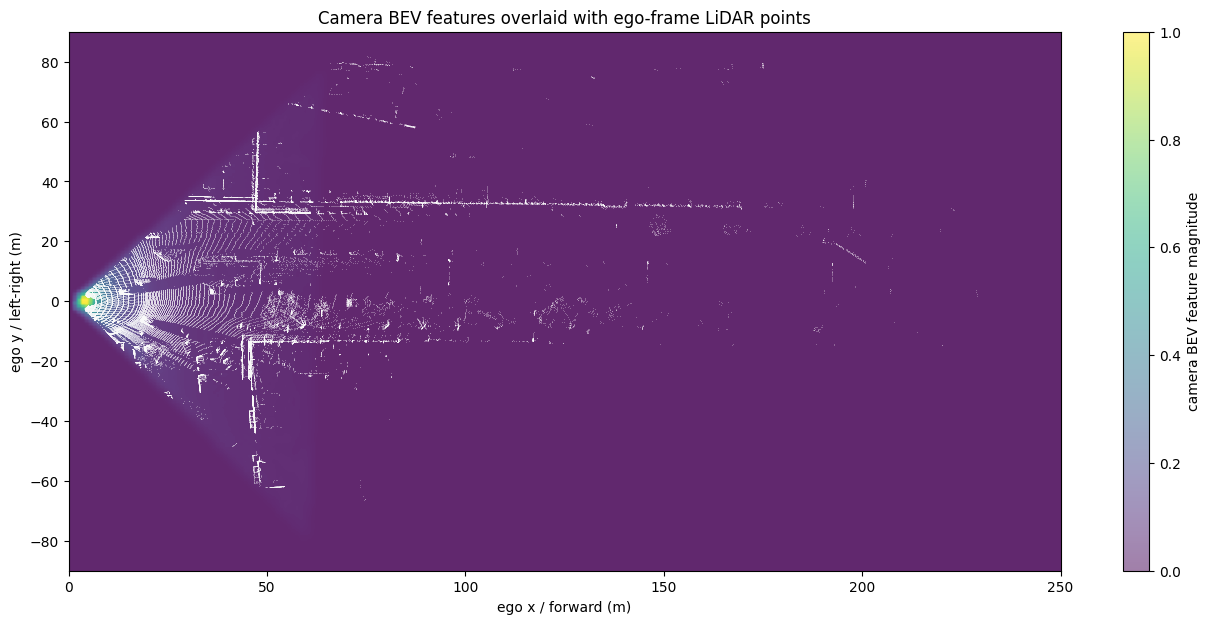

In [31]:
# ============================================================
# Debug overlay:
# camera BEV features + ego-frame LiDAR points
# ============================================================

# ------------------------------------------------------------
# Collapse camera BEV features to a 2D map
# bev_feats shape: [B, C, X, Y]
# ------------------------------------------------------------
bev0 = bev_feats[0].detach().cpu()          # [C, X, Y]
bev_l2 = torch.norm(bev0, dim=0).numpy()    # [X, Y]

print("bev_feats shape:", tuple(bev_feats.shape))
print("bev_l2 shape:", bev_l2.shape)

# ------------------------------------------------------------
# Get ego-frame LiDAR points
# fov_points_ego_xyzi: [N,4]
# ------------------------------------------------------------
pts = fov_points_ego_xyzi
x_pts = pts[:, 0]
y_pts = pts[:, 1]

# Keep only points inside BEV bounds
x_min, x_max, _ = XBOUND
y_min, y_max, _ = YBOUND

mask = (
    (x_pts >= x_min) & (x_pts < x_max) &
    (y_pts >= y_min) & (y_pts < y_max)
)

x_pts = x_pts[mask]
y_pts = y_pts[mask]

print("Num ego-frame points inside BEV bounds:", len(x_pts))

# ------------------------------------------------------------
# Plot BEV feature heatmap and overlay points
# ------------------------------------------------------------
plt.figure(figsize=(16, 7))

# Camera BEV heatmap
plt.imshow(
    bev_l2.T,                      # [Y, X] for imshow
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    aspect="auto",
    alpha=0.85
)

# LiDAR points overlay
plt.scatter(
    x_pts,
    y_pts,
    s=0.2,
    c="white",
    alpha=0.5,
    linewidths=0
)

plt.xlabel("ego x / forward (m)")
plt.ylabel("ego y / left-right (m)")
plt.title("Camera BEV features overlaid with ego-frame LiDAR points")
plt.colorbar(label="camera BEV feature magnitude")
plt.show()